<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer suppurted. Adjust the input and output path if nedded.

In [63]:
# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

# Plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import seaborn as sns

# TF-IDf
from sklearn.feature_extraction.text import TfidfVectorizer

# Graphs
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable
from tqdm import tqdm
from __future__ import annotations
import re

# Loading and Exporting

## Parameters

In [64]:
# dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
# file_name = "Ecuador_part_3.gzip.parquet"  # file name
# dataset_procced_date = "2026_01_08"        # ("%Y_%m_%d")


dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"



account_id_col = "accountid"
top_n = 300 # number of top authors to consider as key authors for each narattive topic
topic_col = "BERTopic_topic_512"


## Load Data

In [65]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
print(f"Running on local/cluster.\nLoading data from: {processed_dataset_path}")

# Load the parquet file
df = pd.read_parquet(processed_dataset_path / f"processed_{file_name}")

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10


## Output

In [66]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Dataset Collums

In [67]:
print
print(f"df shpe: {df.shape}")
print("")
print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shpe: (1468565, 29)

**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool_
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool_
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic_512             | int64
BERTopic_prob512               | float32
BERTopic_

# Topics Distribution

In [68]:
def extract_number(col_name: str) -> int:
    """Extract first integer found in column name.
    
    Args:
        col_name: Column name string.
        
    Returns:
        int: Extracted number or -1 if none found.
    """
    match = re.search(r"\d+", col_name)
    return int(match.group()) if match else -1

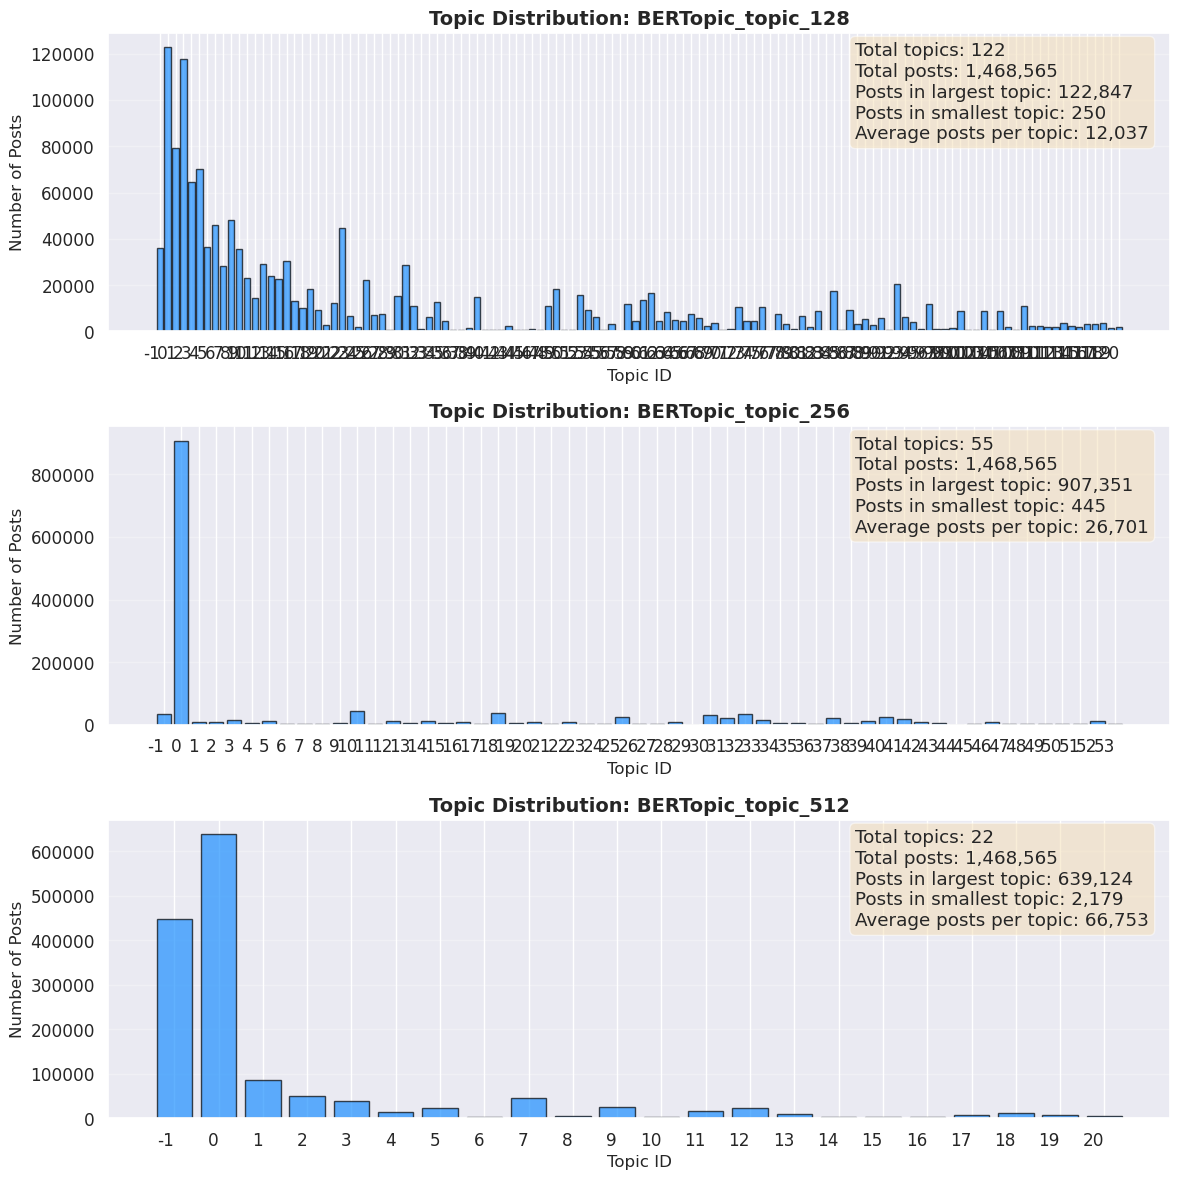

In [69]:
# Find all columns with "BERT", "K_Means", or "topic" in the name (excluding "prob" columns)
topic_columns = [
    col for col in df.columns 
    if any(keyword.lower() in col.lower() for keyword in ["BERT", "K_Means", "topic"])
    and "prob" not in col.lower()
]
topic_columns = sorted(topic_columns, key=extract_number)

# Create distribution plots for each topic column
num_cols = len(topic_columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))

# Handle case where there's only one column (axes won't be an array)
if num_cols == 1:
    axes = [axes]

for idx, col in enumerate(topic_columns):
    # Count posts per topic
    topic_counts = df[col].value_counts().sort_index()
    
    # Create bar plot
    axes[idx].bar(topic_counts.index, topic_counts.values, color='dodgerblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Topic Distribution: {col}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Topic ID", fontsize=12)
    axes[idx].set_ylabel("Number of Posts", fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Set x-ticks to show all topic IDs
    axes[idx].set_xticks(topic_counts.index)
    axes[idx].set_xticklabels(topic_counts.index, rotation=0, ha='right')
    
    # Add count information
    topic_counts = df[col].value_counts()
    axes[idx].text(
        0.98, 0.97,
        f"Total topics: {len(topic_counts)}\n"
        f"Total posts: {len(df):,}\n"
        f"Posts in largest topic: {topic_counts.max():,}\n"
        f"Posts in smallest topic: {topic_counts.min():,}\n"
        f"Average posts per topic: {topic_counts.mean():,.0f}",
        transform=axes[idx].transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        multialignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()

plt.savefig(folder_output_path / f"topic_distributions.png", dpi=300)
plt.show()
plt.close()



# TF-IDF Score

In [70]:
# prams
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]

## Entities

TF-IDF Using *sklearn*

In [71]:
def compute_entities_tfidf(df, entity_col, topic_col="BERTopic_topic"):
    """
    Compute TF-IDF over entities grouped by topic.
    Output shape: rows = entities, columns = topics.

    Args:
        df (pd.DataFrame): Contains [topic_col] and [entity_col] (list of entities).
        entity_col (str): Column with lists of entities per post.
        topic_col (str): Topic label column.

    Returns:
        pd.DataFrame: TF-IDF matrix (rows = entities, columns = topics).
    """

    # 1) Explode rows → (topic, entity)
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .astype({entity_col: str})
    )

    # 2) Build topic "documents"
    topic_docs_df = (
        df_exp.groupby(topic_col)[entity_col]
              .apply(lambda x: " ".join(x))
              .reset_index()
              .rename(columns={entity_col: "doc"})
    )

    # 3) TF-IDF where rows=topics, cols=entities
    vec = TfidfVectorizer(token_pattern=r"\S+")
    X = vec.fit_transform(topic_docs_df["doc"])

    topic_entity_df = pd.DataFrame(
        X.toarray(),
        index=topic_docs_df[topic_col].values,
        columns=vec.get_feature_names_out()
    )

    # 4) Transpose → rows=entities, columns=topics
    entity_topic_df = topic_entity_df.T

    return entity_topic_df

In [72]:
hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col=topic_col)
hashtags_tfidf_df.head()

,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
#26s,0.0,0.000358,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#auxilioo,0.0,0.000000,0.0,0.0,0.0,0.0,0.000182,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#bestupid,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#boomshakalaka,0.0,0.000179,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#buenoasi,0.0,0.000179,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids.
        topic_is (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [74]:
top_entities = get_top_entities(hashtags_tfidf_df, topic_id = -1, top_n=10)
print(top_entities)

['elgobiernodetodos', 'agendagubernamental', 'leydecomunicación', 'ecuador', 'cnt', 'rocíodemoreno', 'venezuela', 'leyfomentoproductivo', 'casaparatodos', 'ecuadorendavos']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [75]:
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    out_col: str = "post_tfidf",
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns.

    Updates df[out_col].
    The TF-IDF score of a posts is the score of its entities in its topic, across all entity columns.

    Args:
        df: Input DataFrame (modified in place).
        topic_col: Column containing topic identifiers.
        entity_cols_lst: List of entity-list columns (each cell is list-like or None).
        out_col: Output column name.

    Returns:
        None.
    """
    df[out_col] = 0.0

    for entity_col in entity_cols_lst:
        # rows=entities, columns=topics
        entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)

        # Build a fast lookup: (entity, topic) -> tfidf
        tfidf_dict = entities_tfidf_df.stack().to_dict()

        for row in tqdm(df.itertuples(index=True), total=len(df), desc=f"Add tf-idf scores of {entity_col}"):
            idx = row.Index
            topic = getattr(row, topic_col)
            ents = getattr(row, entity_col)

            if ents.size == 0: # no entities
                score = 0.0
            else:
                score = float(sum(tfidf_dict.get((e, topic), 0.0) for e in ents))

            df.at[idx, out_col] += score

In [76]:
compute_post_tfidf(df, topic_col, entity_cols_lst)
df[["post_text", "post_tfidf", topic_col]].head()

Add tf-idf scores of ner_entities: 100%|██████████| 1468565/1468565 [01:41<00:00, 14413.03it/s]


,post_text,post_tfidf,BERTopic_topic_512
0,Vamos a cambiar la forma de hacer comunicación...,0.000000,-1
1,"Damos servicio de manejo de prensa, elaboració...",0.000000,-1
2,@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bu...,0.002015,0
3,"Mario, debemos denuciar que en los poderes pub...",0.010293,-1
4,Tambien debemos estar claro que la oposición e...,0.000000,-1


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [77]:
def compute_author_tfidf_to_df(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    out_col: str = "topic_author_tfidf",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
    folder_output_path: Path = None,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        out_col: Output column added to df.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.
        folder_output_path: If given, save the author-topic TF-IDF matrix to this path.

    Returns:
        author_topic_tfidf: Author × topic TF-IDF matrix.
    """

    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_tfidf = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    df[out_col] = df.apply(
        # Pandas aligns by row index = author.
        lambda row: author_topic_tfidf.loc[row[author_col], row[topic_col]],
        axis=1,
    )

    # save
    if folder_output_path is not None:
        author_topic_tfidf.to_parquet(folder_output_path / f"author_topic_tfidf_by_{topic_col}.parquet", compression="gzip")

    return author_topic_tfidf

In [78]:
author_topic_tfidf = compute_author_tfidf_to_df(df, topic_col = topic_col, folder_output_path=folder_output_path)
author_topic_tfidf.head()

BERTopic_topic_512,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
accountid,,,,,,,,,,,,,,,,,,,,,
0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,0.002329,0.018906,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
0005c5f571ae94a562ab590fbcab9138cee6d20507,0.000132,0.001631,0.000000,0.001578,0.003977,0.000000,0.003315,0.0,0.000378,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
0007a45e37da6ae559d6b4b76218874d6ab677234b,0.064927,0.218051,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
000fca065490ad68fbb646d9491061b2abd861703f,0.000000,0.007060,0.000000,0.000000,0.001605,0.000000,0.039710,0.0,0.004970,0.000000,...,0.005754,0.0,0.0,0.0,0.0,0.0,0.0,0.05621,0.0,0.0
0011cb6aa969ab7bc4359a6c445287ca0671aac4c0,0.014280,0.851503,0.023423,0.000000,0.000000,0.010573,0.000000,0.0,0.000000,0.036769,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0


# Key Authors

In [79]:
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 100,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """
    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [80]:
get_topic_top_authors(df, topic=1, topic_col = topic_col)

There are 100 unique key authors in topic 1.


{'0080b858dcdf930f1029c57f65491e8df51b3bebc5',
 '01769a6a8c78cbbe38511b30c649e3b9a69acd7287',
 '01b0efdd37579f669eb5435ed1d747feced02e4b53',
 '06ae71cd26b039f685ffa49c64780bd86f18fdff94',
 '076e32ebd660b01a866cc68f2fc6e723ca15050a3c',
 '0a8807d5066f19a69e7b28d0652c13320f3b7063b0',
 '0d3b88567bf65211bb328ab87185c347edd4f29f9a',
 '11147ad7649a0fccc3dea617a5e495894df11926d8',
 '123e97476d70378a4e1b523764a0e85feab6d4d5d4',
 '13512f0d9a07cecb53b90bfc2856495eb6e40a0036',
 '18a85c6353e0f14a67e79c858ac310d2a556fcd76e',
 '1b6af2310644a99d47f9866e046d675a7fc9a8d667',
 '1d6a261276b5eb20a1e13ddb1ece2bc8d3a30bb4c0',
 '1dd2833786a852fd5ec6169bc3ef88664c8a67b82c',
 '1decb332cd4b7c2dfa969ebc3f5e9e604a5a183f59',
 '1ffd546573448d5ac5ba1dbabd85c087663f24f29f',
 '23d9d97d91127cb7b65b973df67d2e88cb2143500d',
 '24aa1d4c2a5ac62f28e623121cb8dea96209871f94',
 '29c56783516c3f07f96b1674fc5ef3f7e779c13b9d',
 '305856c24fb12546f54a2793b1b78efe51160065d8',
 '3245a5f61e47d0f28fc827984055b3a2752185ec08',
 '3261f9af008

In [81]:
def get_all_topics_key_authors(
    df: pd.DataFrame,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    top_n: int = 10,
) -> tuple[pd.DataFrame, set]:
    """Return a set of authors that are top-n in at least one topic.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        top_n: Top-n authors per topic.

    Returns:
        pd.DataFrame: DataFrame of key authors per topic [topic_col, author_col, score_col].
        set: Authors that appear in the top-n of any topic.
    """
    all_topics_key_authors_df = (
        df[[topic_col, author_col, score_col]]
        .dropna(subset=[topic_col, author_col, score_col])
        .drop_duplicates([topic_col, author_col])   # no aggregation
        .sort_values([topic_col, score_col], ascending=[True, False])
        .groupby(topic_col)
        .head(top_n)
        .reset_index(drop=True)
    )

    print("Sample of all topic key authors:")
    print("Note: authors may appear multiple times for different topics.")
    display(all_topics_key_authors_df.sample(n=10))

    all_topic_top_authors_number = all_topics_key_authors_df.drop_duplicates(subset=[author_col]).shape[0]
    print(f"There are {all_topic_top_authors_number} unique key authors in all topics.")
    
    return all_topics_key_authors_df, set(all_topics_key_authors_df[author_col])

In [82]:
all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(df = df, topic_col = topic_col, top_n = top_n)

Sample of all topic key authors:
Note: authors may appear multiple times for different topics.


,BERTopic_topic_512,accountid,topic_author_tfidf
2794,8,7fe11c1253ceed6aa7e30ae600f94a727a0f314d40,7.335244
5546,17,fa7e68a0bd3add9fcdfe478705771edb5805636eca,0.118181
4631,14,0f9e5a77f0149e2a1db8b8204ca4e713f39019ca83,0.087690
2811,8,feb70b8f45de615a6d6154e12aef3407acb3c3c8b3,6.269144
2704,8,84bddd0547ea84b99c298db8acc2e50e22ba3b6787,12.797970
4197,12,ddf8ec7fce6f33390623fc8f1f4cd0ba42a0b6d9ce,1.352245
3444,10,8ba48388bafd66cc6eaec9f7bd54dc87456f262dcf,0.071431
5353,16,71f8c19d116c767823d5ed60bdf79eca2457b0f5dd,0.000165
1037,2,726d0cb1292a1bfd146ff5ea1ec7567f79c9a31db4,0.515573
2306,6,841fb968f3133b5f8cfc144140abbc2d8c206dc475,0.120631


There are 4150 unique key authors in all topics.


# IO Authors

In [83]:
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control_col: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control_col]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"There are {len(io_authors)} io authors.")

    return io_authors

In [84]:
io_authors_set = get_io_authors_by_ratio(df)

There are 711 io authors.


# Key and IO Authors

## Summary

In [85]:
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set)}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set)}\n"
        f"Number of key authors: {len(all_topics_key_authors_set)}\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key)}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [86]:
save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, output_path = folder_output_path)

### io_key_summary ###

Number of all authors: 21923

Number of IO authors: 711
Number of key authors: 4150

Number of authors that are both IO and key: 529
74.4% of IO authors are also key authors

Saved summary to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/io_key_authors_summary.txt


## Venn Plot

In [87]:
def plot_venn_3_sets(
    all_authors_set: set,
    all_topics_key_authors_set: set,
    io_authors_set: set,
    title: str = "Venn Diagram",
    set_labels: tuple[str, str, str] = ("All authors", "Key authors", "IO authors"),
    folder_output_path: str | Path = None,
) -> None:
    """Plot a 3-set Venn diagram for author subsets.

    Args:
        all_authors_set: Set of all author IDs in the dataset/graph.
        all_topics_key_authors_set: Set of authors selected as key-authors across topics.
        io_authors_set: Set of IO-labeled authors.
        title: Figure title.
        set_labels: Labels for the three sets (A, B, C) in the diagram.
    """
    # Normalize to strings for consistent overlap
    A = set(map(str, all_authors_set))
    B = set(map(str, all_topics_key_authors_set))
    C = set(map(str, io_authors_set))

    plt.figure(figsize=(7, 6))
    v = venn3(
        subsets=(A, B, C),
        set_labels=set_labels,
        set_colors=(
        "#6081B5",  # All
        "#AA6B0C",  # Key 
        "#9E4950",  # IO
    ),
        alpha=0.8,
    )

    plt.title(title)
    plt.tight_layout()


    # Save figure
    if folder_output_path is not None:
      folder_output_path = Path(folder_output_path)
      plt.savefig(folder_output_path / "venn.png", dpi=300)
      print(f"Saved fig to: {folder_output_path}")

    plt.show()
    plt.close()

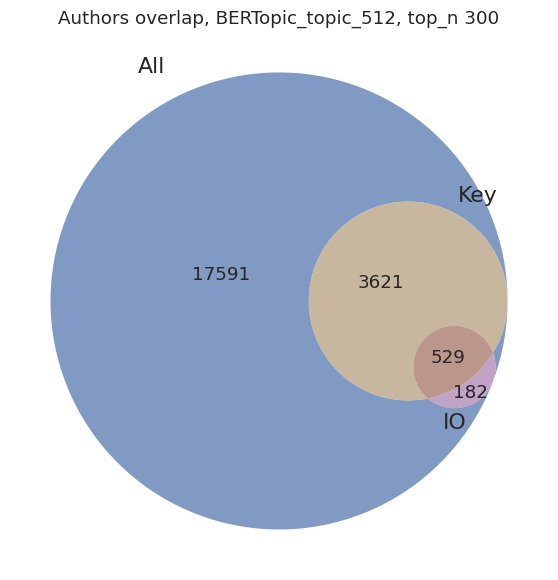

<Figure size 640x480 with 0 Axes>

In [88]:
# Compute all authors set
all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

plot_venn_3_sets(
    all_authors_set=all_authors_set,
    all_topics_key_authors_set=all_topics_key_authors_set,
    io_authors_set=io_authors_set,
    title=f"Authors overlap, {topic_col}, top_n {top_n}",
    set_labels=("All", "Key", "IO"),
)

plt.savefig(folder_output_path / f"venn_{topic_col}_top_n_{top_n}.png", dpi=300)
plt.show()
plt.close()

## Venn Plot: complete pipline

In [89]:
def compute_and_plot_venn(
    df: pd.DataFrame,
    all_authors_set: set,
    io_authors_set: set,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    top_n: int = 10,
    folder_output_path: str | Path = None,
) -> set:
    """Compute key authors across topics and plot Venn diagram.

    Args:
        df: DataFrame with posts and author-topic TF-IDF scores.
        all_authors_set: Set of all authors in the dataset.
        io_authors_set: Set of IO-labeled authors.
        score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        top_n: Top-n authors per topic.
        folder_output_path: Path to save the Venn diagram.

    Returns:
        set: all_topics_key_authors_set (authors that are top-n in at least one topic)
    """
    # 1) Compute key authors across all topics
    all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        score_col=score_col,
        author_col=author_col,
        topic_col=topic_col,
        top_n=top_n,
    )
    all_topics_key_authors_set = set(map(str, all_topics_key_authors_set))

    # 2) Plot Venn diagram
    plot_venn_3_sets(
        all_authors_set=all_authors_set,
        all_topics_key_authors_set=all_topics_key_authors_set,
        io_authors_set=io_authors_set,
        title=f"Authors overlap, {topic_col}, top {top_n}",
        set_labels=("All", "Key", "IO"),
        folder_output_path=folder_output_path,
    )

    return all_topics_key_authors_set


Sample of all topic key authors:
Note: authors may appear multiple times for different topics.


,BERTopic_topic_512,accountid,topic_author_tfidf
2094,9,5f240b01f2380e97531f4caebaa6d45e080b2211a3,9.914072
1151,4,00ba2a71955da135b125513860e5ac37a9a3f4a3b8,1.903748
1396,5,fcf7b9114e4c678b8c5b64d11617c2d5b1a37727f1,0.664840
1532,6,37378e8fbfc602907e95a59e39814db60f3611c27d,8.114548
3,-1,eb67a28395e8e79db83506a7fd6a937d18ba84d57a,1444.764597
3179,14,13a38b2ebabae523130e15d88873a54a77305173d3,0.048996
2537,11,1befa45b4f139eae09ad6d845e5f9a15feb4e034a2,0.466965
1812,8,bc6e16b48eefb34f58493c7e76224cfa4be9f11dc9,11.057510
1620,7,563df78287352299763cec5707a04f6b5935c184cc,75.168115
1970,8,b48baa7b1e41ea4815eb8514aa1c5172b96424fd5a,4.611065


There are 2900 unique key authors in all topics.
Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10


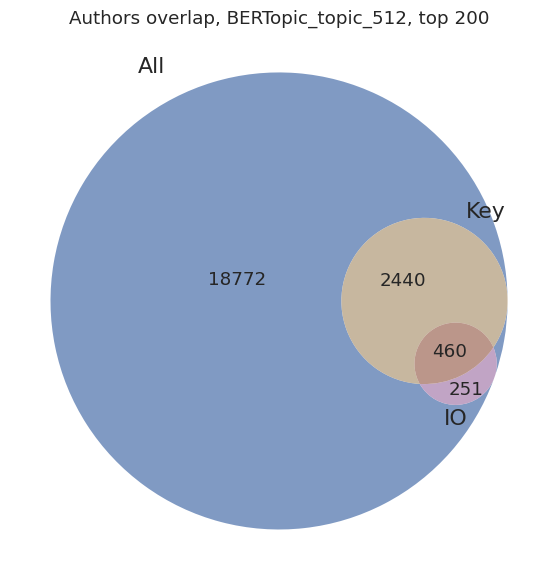

In [90]:
# Run complete pipeline to compute and plot Venn diagram
all_topics_key_authors_set = compute_and_plot_venn(
    df=df,
    all_authors_set=all_authors_set,
    io_authors_set=io_authors_set,
    topic_col=topic_col,
    top_n=200,
    folder_output_path=folder_output_path,
)

# Networkx Graphs

## Parameters

In [91]:
account_relations = [
    ("accountid", "in_reply_to_accountid"),
    ("accountid", "account_mentions"),
    ("accountid", "reposted_accountid"),
]

## Build Bipartite Account ↔ Account Graph

In [92]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    topic_col: str = "BERTopic_topic",
    io_authors: set | None = None,
) -> None:
    """Add weighted edges to a graph and annotate author nodes.

    This builds edges from co-occurrence counts of (src, dst) pairs.
    Edge weights are incremented by `weight` for each co-occurrence.
    Annotates nodes with: (optional)
        * io_author: 1 if author in `io_authors`, else 0
        * score: aggregated author-topic score 
        * participan_at_topics: list of topics the author is active in
      

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_df: Optional DataFrame with author-topic metadata.
        author_col: Column in `all_topics_key_authors_df` containing author IDs.
        score_col: Column in `all_topics_key_authors_df` containing author-topic score.
        topic_col: Column in `all_topics_key_authors_df` containing topic label.
        io_authors: Optional set of IO-labeled authors.

    Returns:
        None
    """

    # make pairs of src-dst
    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # author_meta: (score_map, topics_map)
    author_meta = None
    if all_topics_key_authors_df is not None:
        tmp = all_topics_key_authors_df[[author_col, score_col, topic_col]].dropna()
        tmp[author_col] = tmp[author_col].astype(str)

        key = set(tmp[author_col].unique())
        pairs = pairs[pairs[src_col].isin(key) & pairs[dst_col].isin(key)]

        # score per author
        author_sum_score_map: dict[str, float] = tmp.groupby(author_col)[score_col].sum().to_dict()
        # Topics per author, sorted by score descending (highest-score topics first)
        author_topics_map : dict[str, list] = (
            tmp.sort_values([author_col, score_col], ascending=[True, False])
            .groupby(author_col)[topic_col]
            .apply(list)
            .to_dict()
        )
        
        author_meta = (author_sum_score_map , author_topics_map)

    # io_author set
    if io_authors is not None:
        io_authors = set(map(str, io_authors))


    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count")
    print("pairs.value_counts head:")
    display(counts.head())

    for row in counts.itertuples(index=False):
        src = getattr(row, src_col)
        dst = getattr(row, dst_col)
        w = int(row.count) * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            continue # skip to next row, dont update labels again

        # add the edge (automatically add nodes if needed)
        G.add_edge(src, dst, weight=w)
            
        # add lables
        for author in [src, dst]:
            # add io_author label
            if io_authors is not None:
                G.nodes[author]["io_author"] = int(author in io_authors)
            # add author meta
            if author_meta is not None:

                G.nodes[author][f"all_topics_scores_sum"] = author_meta[0][author]

                author_topics = author_meta[1][author]
                G.nodes[author]["highest_score_topic"] = author_topics[0] # the topic with the highest score
                G.nodes[author]["participan_at_topics"] = ",".join(map(str, author_topics))
                
    return None

In [93]:
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    io_authors: set | None = None,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    output_path: Path | None = None,
    topic_col: str = "BERTopic_topic_512",
    is_directed_graphs: bool = True,
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_df: Optional filter for key authors onlya (author-topic metadata).
        output_path: If provided, writes `<output_path>/<topic_col>_accounts_graph.gexf`.
        is_directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).
        topic_col: Topic column name (used in add_relation_edges).


    Returns:
        nx.DiGraph: The constructed accounts graph.
    """
    # create graph
    if is_directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = f"{topic_col}_accounts_graph"

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if all_topics_key_authors_set is None:
        print("Warning: all_topics_key_authors_set is None. No filtering will be applied.")

    # Add nodes and edges
    for src_col, dst_col in account_relations:
        print(f"[build_accounts_graph] Now adding edges of {dst_col}")
        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_df=all_topics_key_authors_df,
            io_authors=io_authors,
            topic_col = topic_col,
        )

    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{topic_col}_accounts_graph.gexf"
        nx.write_gexf(G, graph_output_path)
        print(f"Saved graph to: {graph_output_path}")

    return G

In [94]:
G_accounts = build_accounts_graph(
    df=df,
    account_relations=account_relations,
    io_authors=io_authors_set,
    all_topics_key_authors_df=all_topics_key_authors_df,
    output_path=folder_output_path,
    topic_col="BERTopic_topic_512",
)

[build_accounts_graph] Now adding edges of in_reply_to_accountid
pairs.value_counts head:


,accountid,in_reply_to_accountid,count
0,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,d77588c443644c33536cb68bb7610be2626b47b9b9,147
1,1ab9531749792f126aeb0cde29e0d4628293ff2326,0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,95
2,70977662b5d96b2cf7604f9de940a581576abcd991,d77588c443644c33536cb68bb7610be2626b47b9b9,80
3,71b45b9cfbe033acf94c15763207cc9f35746ad22a,d77588c443644c33536cb68bb7610be2626b47b9b9,70
4,71f8326cc25135b9f8c10b8484a1e482e92443c810,f0accd94a7a419098914844d155807fbbd99892488,53


[build_accounts_graph] Now adding edges of account_mentions
pairs.value_counts head:


,accountid,account_mentions,count
0,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,d77588c443644c33536cb68bb7610be2626b47b9b9,775
1,71f8326cc25135b9f8c10b8484a1e482e92443c810,fcc237f8fdb4f4ee3b15b5150e4a8f75ac0e44ff7e,656
2,71f8326cc25135b9f8c10b8484a1e482e92443c810,f0accd94a7a419098914844d155807fbbd99892488,628
3,71f8326cc25135b9f8c10b8484a1e482e92443c810,33461cd78e23ac28bdfd3216ac29c423cff776e020,572
4,a7b965c1b1bf78ef15777fd79926127244502d53e2,f0accd94a7a419098914844d155807fbbd99892488,519


[build_accounts_graph] Now adding edges of reposted_accountid
pairs.value_counts head:


,accountid,reposted_accountid,count
0,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,d77588c443644c33536cb68bb7610be2626b47b9b9,432
1,71cc57155d061d447c2c65756c7dfd6873e403a097,d77588c443644c33536cb68bb7610be2626b47b9b9,383
2,71cc57155d061d447c2c65756c7dfd6873e403a097,d1fed0cb1f9a0ced49d4220d2bc911d7819d6406d6,377
3,70977662b5d96b2cf7604f9de940a581576abcd991,d77588c443644c33536cb68bb7610be2626b47b9b9,322
4,4356e554e26d3b89f45ecfdee41cc2bd57a86bf2bb,d77588c443644c33536cb68bb7610be2626b47b9b9,301


Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_accounts_graph.gexf


## Plot Accounts Graph

In [95]:
def plot_accounts_graph(
    G: nx.Graph,
    folder_output_path: str | Path | None = None,
    graph_name: str = "accounts_graph",
    figsize: tuple = (12, 12),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
):
    """Plot a NetworkX graph and highlight IO authors.
    
    Args:
        G: Input NetworkX graph with node attribute 'io_author' (1 for IO, 0 for non-IO).
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: Base name for the saved plot file.
        figsize: Figure size for the plot.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX. Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
    """
    if key_authors is not None:
        key_authors = set(map(str, key_authors))
        G_plot = G.subgraph(key_authors)
    else:
        G_plot = G

    n_nodes = G_plot.number_of_nodes()
    n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
    n_legitimate = n_nodes - n_io
    
    print(f"Plotting graph with {n_nodes} nodes: {n_io} IO authors, {n_legitimate} legitimate authors")
    
    plt.figure(figsize=figsize)
    
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G_plot, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G_plot)
    elif layout == "random":
        pos = nx.random_layout(G_plot, seed=42)
    elif layout == "shell":
        pos = nx.shell_layout(G_plot)
    elif layout == "spectral":
        pos = nx.spectral_layout(G_plot)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G_plot)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    node_colors = [
        "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
        for n in G_plot.nodes
    ]

    nx.draw(
        G_plot,
        pos,
        node_size=30,
        node_color=node_colors,
        edge_color="gray",
        width=0.5,
        alpha=0.8,
        with_labels=False,
    )

    legend_elements = [
        mpatches.Patch(color="steelblue", label=f"Non-IO author ({n_legitimate} nodes)"),
        mpatches.Patch(color="red", label=f"IO author ({n_io} nodes)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=10)

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()


Plotting graph with 1639 nodes: 448 IO authors, 1191 legitimate authors
Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_accounts_graph_spring.png


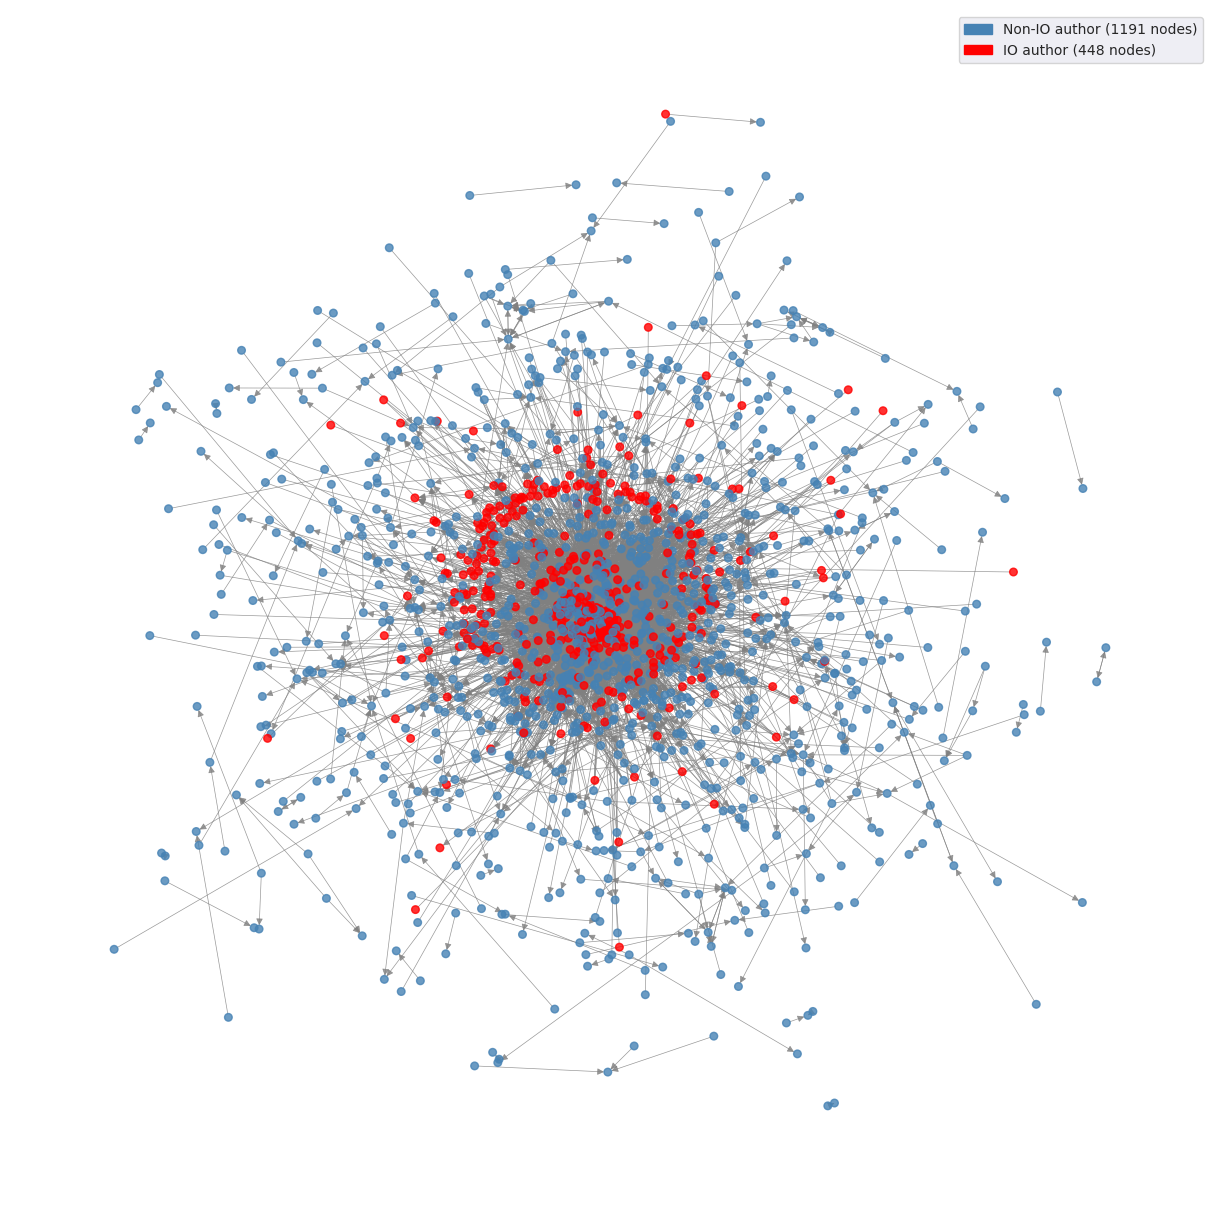

In [96]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, graph_name = f"{topic_col}_accounts_graph", layout="spring")

# IO Indicators

e.g, centralities, core number

## Compute Indicators


[Facebook Network Analysis](https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html) </br>
[NX Algoritms](https://networkx.org/documentation/stable/reference/algorithms/index.html)

In [97]:
def compute_indicators(G: nx.Graph, output_folder_path: str | Path | None = None) -> pd.DataFrame:
    """Compute multiple graph centralities.

    https://networkx.org/documentation/stable/reference/algorithms/index.html

    Returns a DataFrame indexed by author/node with:
      - degree centrality (centrality)
      - betweenness centrality (centrality)
      - closeness centrality (centrality)
      - harmonic centrality (centrality)
      - load centrality (centrality)
      - eigenvector centrality (centrality)
      - node_clique_number (clique)
      - pagerank (link analysis)
      - kcore (core)
      - clustering coefficient (clustering)
      - triangles (clustering)
      - square_clustering (clustering)
      - sum tfidf score (key-authors score) # not NX

    Args:
        G: NetworkX graph

    Returns:
        indicators_df: Centrality measures per node.
    """

    # Degree centrality
    print("Calculating: degree_centrality")
    degree = nx.degree_centrality(G)
    
    # Betweenness centrality
    print("Calculating: betweenness_centrality")
    betweenness = nx.betweenness_centrality(G, normalized=True)

    # Closeness centrality
    # print("Calculating: closeness_centrality")
    # closeness = nx.closeness_centrality(G)

    # Harmonic centrality
    print("Calculating: harmonic_centrality")
    harmonic = nx.harmonic_centrality(G)

    # Load centrality
    print("Calculating: load_centrality")
    load = nx.load_centrality(G, normalized=True)

    # Eigenvector centrality
    print("Calculating: eigenvector_centrality")
    eigen = nx.eigenvector_centrality(G, max_iter=2000)

    # node_clique_number # high correlation with k-core
    # print("Calculating: node_clique_number")
    # node_clique_number = nx.node_clique_number(G.to_undirected())
    
    # PageRank
    print("Calculating: pagerank")
    pagerank = nx.pagerank(G)

     # K-core number
    print("Calculating: core_number")
    kcore = nx.core_number(G)

    # Clustering
    print("Calculating: clustering")
    clustering = nx.clustering(G)

    # triangles # high correlation with k-core
    # print("Calculating: triangles")
    # triangles = nx.triangles(G.to_undirected())

    # Square clustering
    print("Calculating: square_clustering")
    square_clustering = nx.square_clustering(G)

    # sum tfidf score
    print("Calculating: all_topics_scores_sum")
    all_topics_scores_sum: dict[str, float] = {
    node: G.nodes[node]["all_topics_scores_sum"]
    for node in G.nodes
}

    # Build DataFrame
    node_indicators_df = pd.DataFrame(
        {
            "degree_centrality": degree,
            "betweenness_centrality": betweenness,
            # "closeness_centrality": closeness, # high correlation with closeness
            "harmonic_centrality": harmonic, 
            "eigenvector_centrality": eigen,
            # "load_centrality": load, # high correlation with betweenness
            # "node_clique_number": node_clique_number, # high correlation with k-core
            "pagerank": pagerank,
            "kcore": kcore,
            "clustering": clustering,
            # "triangles": triangles, # high correlation with k-core
            "square_clustering": square_clustering,
            "tfidf_sum": all_topics_scores_sum,
        }
    )

    node_indicators_df.index.name = "accountid"


    if output_folder_path is not None:
        node_indicators_df_path = Path(output_folder_path) / "node_centralities.parquet"
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")
        print(f"node_indicators_df is saved to: {node_indicators_df_path}")


    return node_indicators_df

In [98]:
node_indicators_df = compute_indicators(G_accounts)
node_indicators_df.head()

Calculating: degree_centrality
Calculating: betweenness_centrality
Calculating: harmonic_centrality
Calculating: load_centrality
Calculating: eigenvector_centrality
Calculating: pagerank
Calculating: core_number
Calculating: clustering
Calculating: square_clustering
Calculating: all_topics_scores_sum


,degree_centrality,betweenness_centrality,harmonic_centrality,eigenvector_centrality,pagerank,kcore,clustering,square_clustering,tfidf_sum
accountid,,,,,,,,,
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,0.124542,0.002198,170.436833,1.205255e-01,0.001192,87,0.474915,0.457832,2667.306805
d77588c443644c33536cb68bb7610be2626b47b9b9,0.236874,0.000791,671.200000,1.490930e-01,0.165573,73,0.047007,0.108696,64.983037
1ab9531749792f126aeb0cde29e0d4628293ff2326,0.000611,0.000000,0.000000,4.125288e-14,0.000163,1,0.000000,0.000000,2.293081
0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,0.002442,0.000113,2.000000,6.187932e-13,0.000342,2,0.083333,0.000000,0.713886
70977662b5d96b2cf7604f9de940a581576abcd991,0.121490,0.021425,183.571176,1.180327e-01,0.001032,87,0.491797,0.471822,1712.931508


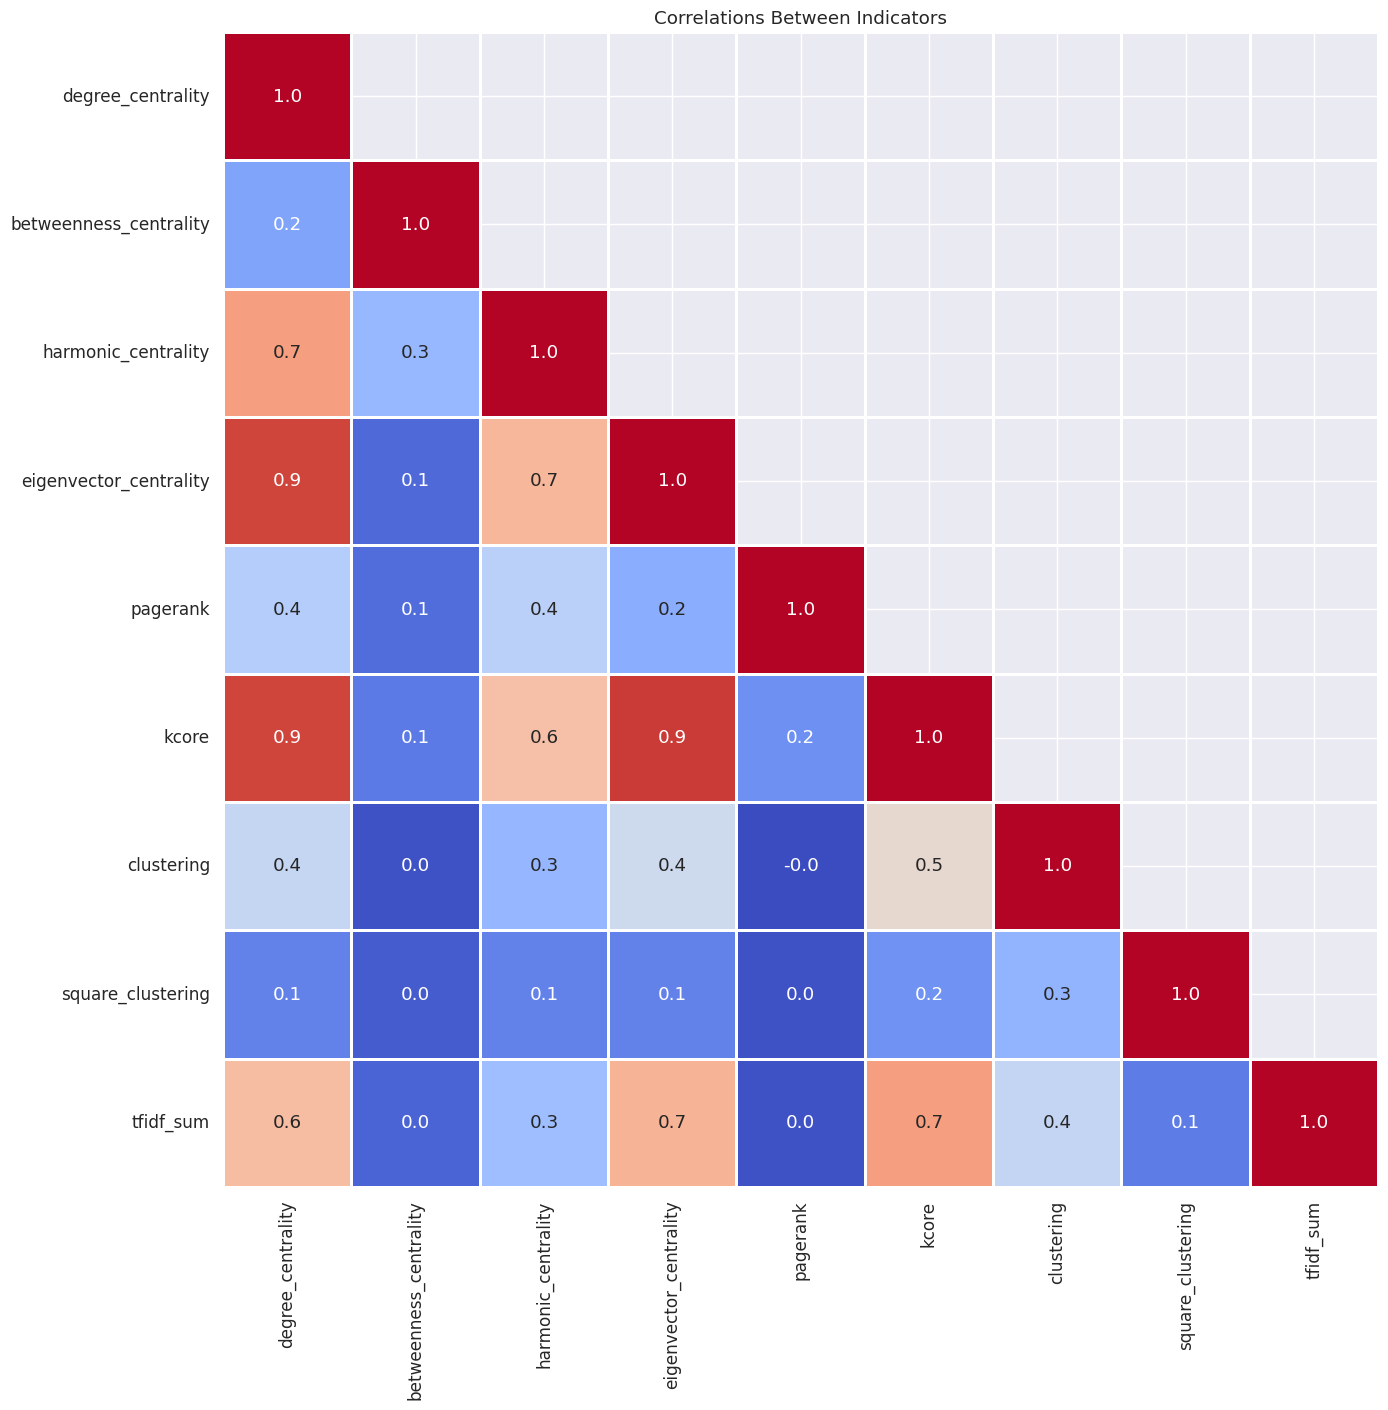

Saved indicators correlation heatmap to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_correlation_heatmap.png


In [99]:
# Display correlations between indicators.
corr = node_indicators_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.set(font_scale=1.1)
plt.figure(figsize=(15, 15))
sns.heatmap(corr,
            annot=True,
            fmt='.1f',
            cmap='coolwarm',
            square=True,
            mask = mask,
            linewidths=1,
            cbar=False)
plt.title("Correlations Between Indicators")
plt.show()


plt.savefig(folder_output_path / "indicators_correlation_heatmap.png", dpi=300, bbox_inches="tight")
print(f"Saved indicators correlation heatmap to: {folder_output_path / 'indicators_correlation_heatmap.png'}")

plt.close()

## Z-Score

In [100]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [101]:
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [102]:
node_indicators_zscore_df = compute_zscore(node_indicators_df)
print("#### zscore ####")
node_indicators_zscore_df.head()

#### zscore ####


,degree_centrality,betweenness_centrality,harmonic_centrality,eigenvector_centrality,pagerank,kcore,clustering,square_clustering,tfidf_sum
accountid,,,,,,,,,
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,5.203976,1.145439,1.796023,4.782589,0.098001,4.206947,1.472469,0.291212,9.576508
d77588c443644c33536cb68bb7610be2626b47b9b9,10.256076,0.328499,8.401036,5.978746,27.806497,3.454655,-0.475008,-0.073460,-0.045370
1ab9531749792f126aeb0cde29e0d4628293ff2326,-0.369808,-0.130679,-0.452021,-0.263969,-0.075285,-0.414275,-0.688944,-0.186993,-0.277161
0403388bc14cc27d9ced0a829f8cbbaae332bd4a6d,-0.287436,-0.064988,-0.425641,-0.263969,-0.045154,-0.360540,-0.309681,-0.186993,-0.283000
70977662b5d96b2cf7604f9de940a581576abcd991,5.066691,12.310492,1.969264,4.678211,0.071083,4.206947,1.549301,0.305825,6.047784


## Account Indicators Summery

In [103]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [104]:
suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


show_account_indicators(
    accountid = suspect_accountid,
    node_indicators_df = node_indicators_df,
    node_indicators_zscore_df = node_indicators_zscore_df,
)

Account ID: 9e068947d6342824fe3782f77c0f1e93eed987c0c9


,indicator,value,z_score
0,degree_centrality,0.061,2.35
1,betweenness_centrality,0.001,0.73
2,harmonic_centrality,241.110,2.73
3,eigenvector_centrality,0.122,4.84
4,pagerank,0.002,0.21
5,kcore,70.000,3.29
6,clustering,0.429,1.27
7,square_clustering,0.028,-0.16
8,tfidf_sum,1.561,-0.28


## Information Gain

In [105]:
def compute_indicators_information_gain(
    node_indicators_df: pd.DataFrame,
    io_authors: set,
    folder_path: str | Path | None = None,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_indicators_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).
        folder_path: Optional path to save the information gain results.

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    authors = node_indicators_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_indicators_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_indicators_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    # Save results
    if folder_path is not None:
        folder_path = Path(folder_path)
        info_gain_output_path = folder_path / "indicators_information_gain.parquet"
        mi_series.to_frame().to_parquet(info_gain_output_path, compression = "gzip")
        print(f"Saved information gain results to: {info_gain_output_path}")

    return mi_series

In [106]:
mi_series = compute_indicators_information_gain(node_indicators_df, io_authors_set, folder_output_path)
display(mi_series)

Saved information gain results to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_information_gain.parquet


tfidf_sum                 0.120930
kcore                     0.089498
clustering                0.089118
eigenvector_centrality    0.070659
harmonic_centrality       0.069016
square_clustering         0.062980
pagerank                  0.046483
degree_centrality         0.040382
betweenness_centrality    0.016370
Name: information_gain, dtype: float64

## Plot

### Indicators Information Gain

In [107]:
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "indicators_information_gain.png",
    title: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
        title: Title of the plot.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain")
    plt.xlabel("Indicators")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_indicators_information_gain.png


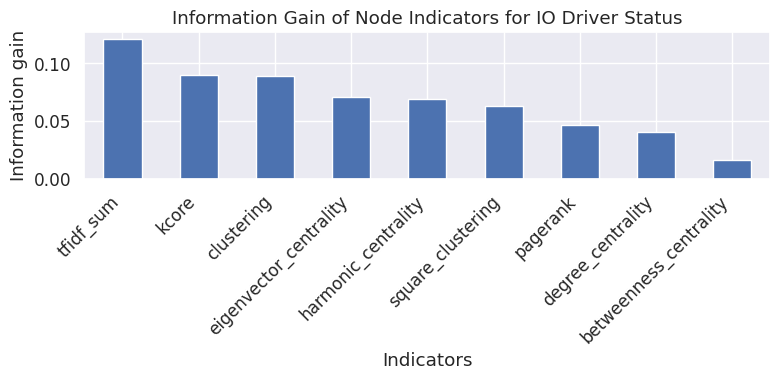

In [108]:
plot_indicators_information_gain(mi_series, folder_output_path, filename=f"{topic_col}_indicators_information_gain.png")

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_indicators_z_score_information_gain.png


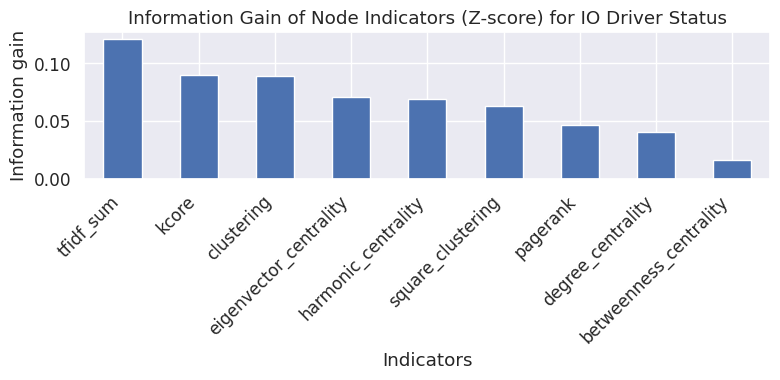

In [109]:
z_score_mi_series = compute_indicators_information_gain(node_indicators_zscore_df, io_authors_set)
plot_indicators_information_gain(z_score_mi_series, folder_output_path, filename=f"{topic_col}_indicators_z_score_information_gain.png", title = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

### Distributions

In [110]:
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of centrality features for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved indicators distributions to: {distributions_output_path}")

    plt.show()
    plt.close(fig)

Saved indicators distributions to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_distributions.png


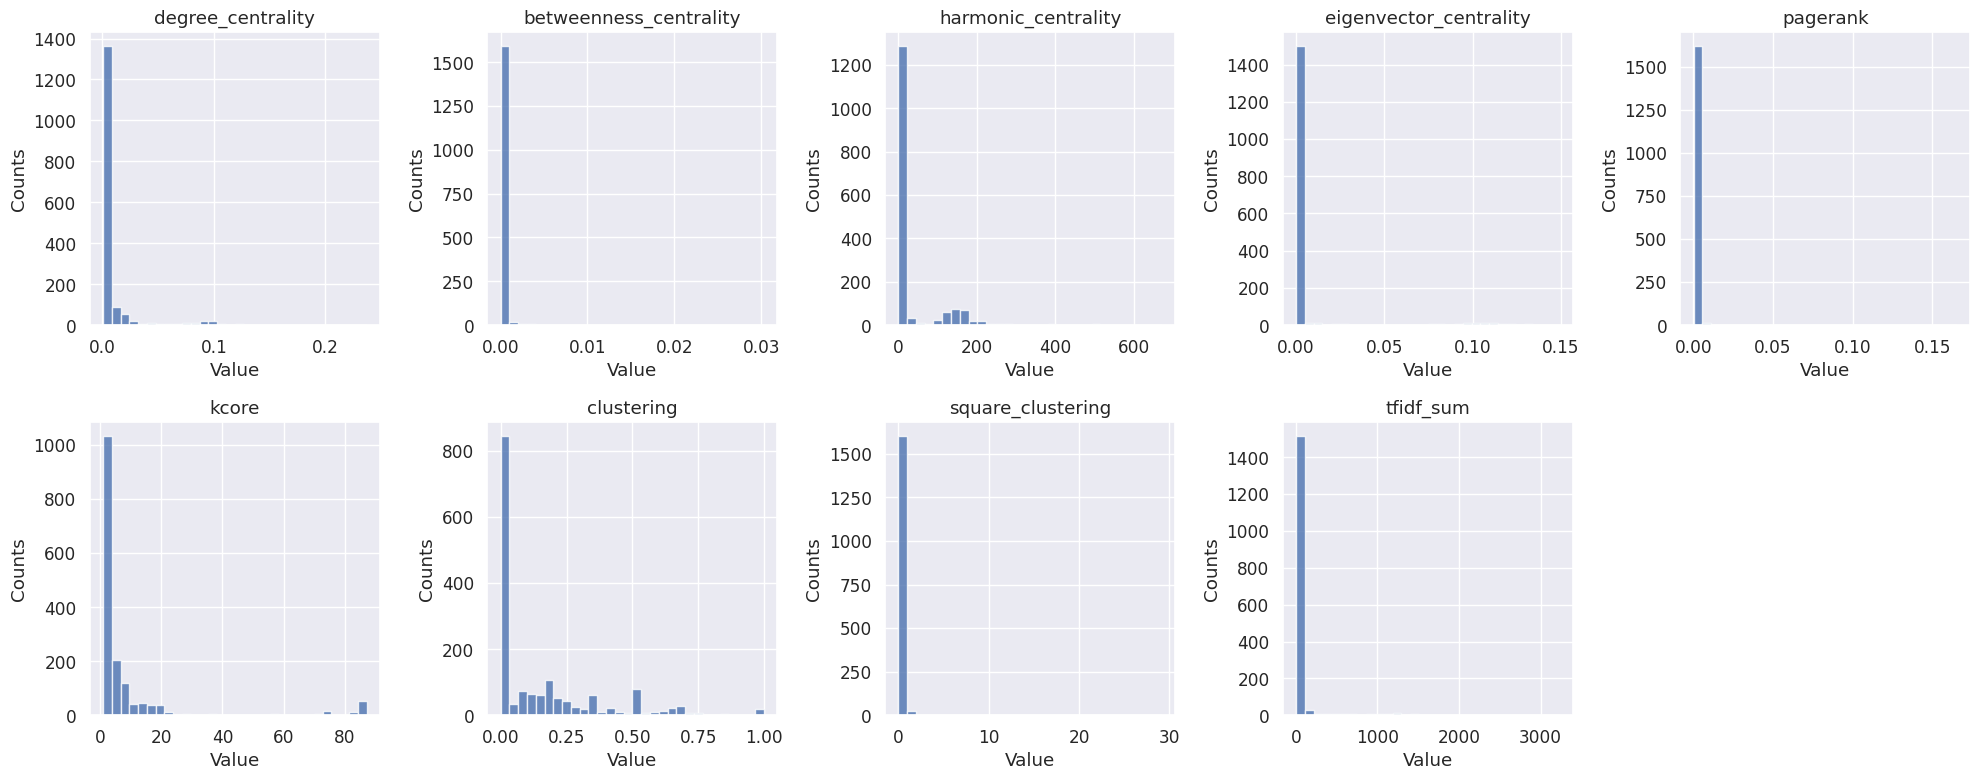

In [111]:
plot_indicators_distributions(node_indicators_df, folder_output_path)

### Boxplots

In [112]:
def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set, output_path: str | Path= None) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
        output_path: Optional path to save the plot image.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 3 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_indicator_boxplots.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {distributions_output_path}")
    
    plt.show()
    plt.close()

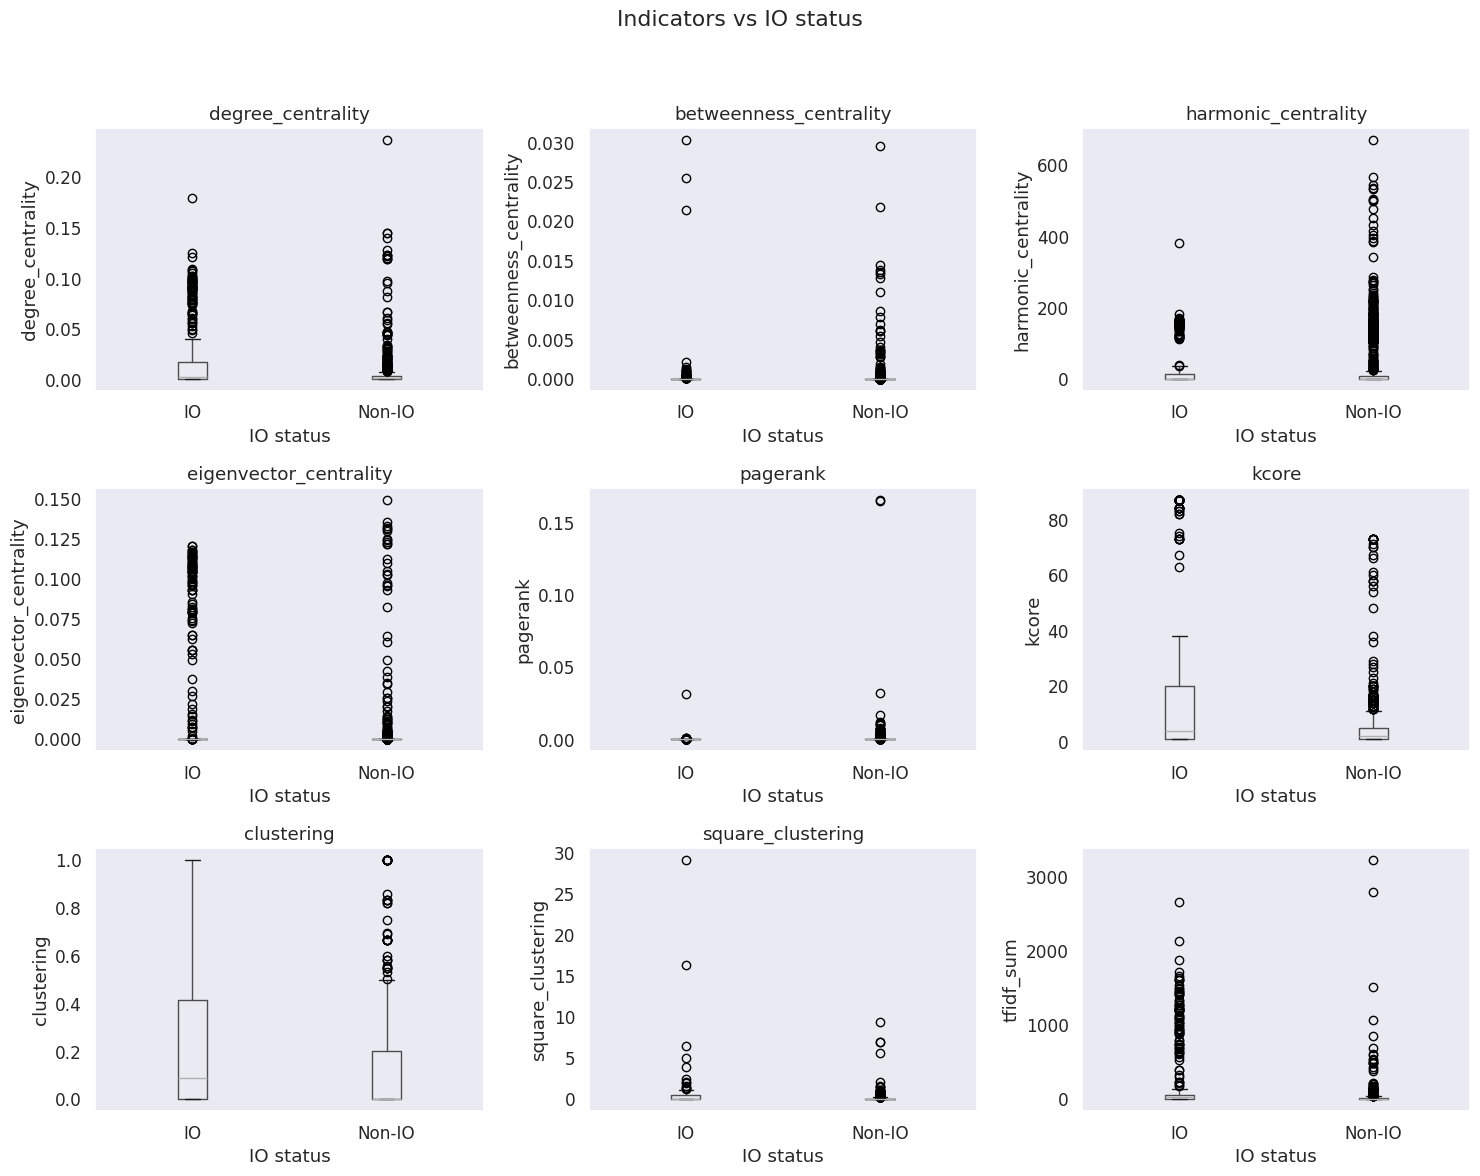

In [113]:
plot_indicator_boxplots(node_indicators_df, io_authors_set)

# Linear Coefficients

In [114]:
import pandas as pd
from pandas.api.types import is_numeric_dtype

io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)

# make it a Series with the same index
io_binary = pd.Series(io_mask.astype(int), index=node_indicators_df.index, name="io_binary")

indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

coefficients = {}
for indicator in indicators:
    coefficients[indicator] = node_indicators_df[indicator].corr(io_binary)  # Pearson by default

coefficients_df = (
    pd.Series(coefficients, name="correlation")
      .sort_values(ascending=False)
      .to_frame()
)

display(coefficients_df)


,correlation
kcore,0.345022
tfidf_sum,0.290455
degree_centrality,0.269365
eigenvector_centrality,0.247288
clustering,0.164944
square_clustering,0.109642
betweenness_centrality,0.006037
harmonic_centrality,-0.011515
pagerank,-0.035659


In [118]:
import matplotlib.pyplot as plt

def plot_io_correlations(coefficients_df, title="Indicator Linear Coefficients with IO Label"):
    """Plot correlation of graph indicators with IO binary label.

    Args:
        coefficients_df: DataFrame with index=indicator, column 'correlation'.
        title: Plot title.
    """
    df = coefficients_df.sort_values("correlation")

    plt.figure(figsize=(8, max(4, 0.35 * len(df))))
    plt.barh(df.index, df["correlation"])
    plt.axvline(0)
    plt.xlabel("Correlation with IO (binary)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(folder_output_path / "indicators_io_linear_coefficients.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

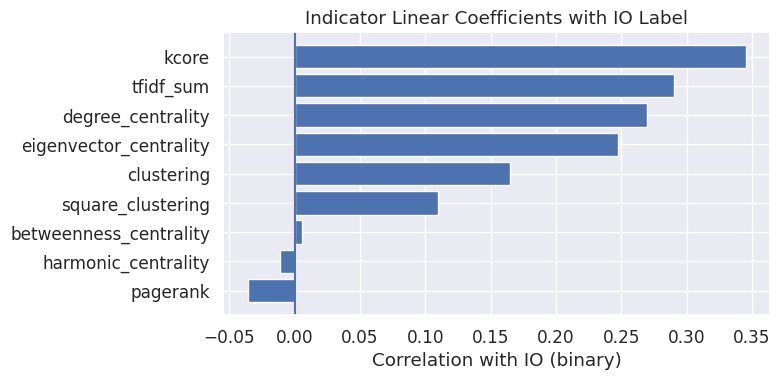

In [119]:
plot_io_correlations(coefficients_df)

# Parameter Sweep: Information Gain Analysis

This section implements functions to run key_authors_graph with different min_topic_size and top_n values, compute total information gain, and visualize results.

In [120]:
from __future__ import annotations

from itertools import product
from typing import Iterable, Sequence

## One Experiment

In [125]:
def run_io_indicator_ig_experiment(
    df: pd.DataFrame,
    min_topic_size: int,
    top_n: int,
    account_relations: Iterable[tuple[str, str]],
    is_directed_graphs: bool,
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> pd.DataFrame:
    """Run a full IO experiment pipeline and return summary metrics.

    Pipeline:
      1) topic_col = f"{base_topic_col}_{min_topic_size}"
      2) get_io_authors_by_ratio(...) -> io_authors
      3) get_all_topics_key_authors(...) -> all_topics_key_authors_df
      4) build_accounts_graph(...) -> G
      5) compute_indicators(G) -> node_indicators_df
      6) compute_centrality_information_gain(...) -> IG per indicator
      7) return sum + mean IG.

    Returns:
        Single-row DataFrame with min_topic_size, top_n, is_directed_graphs,
        ig_sum, ig_mean (+ helpful counts).
    """
    # ---------- 0) topic_col ----------
    topic_col = f"{base_topic_col}_{min_topic_size}"
    if topic_col not in df.columns:
        raise KeyError(f"[MY ERROR] topic_col '{topic_col}' not found in df.columns")

    # ---------- 1) IO authors ----------
    io_authors = get_io_authors_by_ratio(
        df=df,
        author_col=author_col,
        is_io_control_col=is_io_control_col,
        io_threshold=io_threshold,
        min_posts=min_posts,
    )
    io_authors_set = set(map(str, io_authors))

    # ---------- 2) key authors ----------
    all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        score_col=score_col,
        author_col=author_col,
        topic_col=topic_col,
        top_n=top_n,
    )

    # ---------- 3) build graph ----------
    G = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors,
        all_topics_key_authors_df=all_topics_key_authors_df,
        is_directed_graphs=is_directed_graphs,
        topic_col=topic_col,
    )

    # ---------- 4) compute indicators ----------
    node_indicators_df = compute_indicators(G)

    # ---------- 5) IG ----------
    ig_series = compute_indicators_information_gain(node_indicators_df, io_authors_set)
    ig_series = pd.to_numeric(ig_series, errors="coerce").dropna()

    ig_sum = float(ig_series.sum())
    ig_mean = float(ig_series.mean())

    # ---------- output ----------
    return pd.DataFrame([{
        "model": base_topic_col,
        "min_topic_size": int(min_topic_size),
        "top_n": int(top_n),
        "is_directed_graphs": bool(is_directed_graphs),
        "ig_sum": ig_sum,
        "ig_mean": ig_mean,
        "n_indicators": int(len(ig_series)),
        "n_nodes": int(node_indicators_df.shape[0]),
        "n_io_authors": int(len(io_authors_set)),
        "n_account_relations": int(len(account_relations)),
    }])

## Grid Experiments

In [126]:
def run_io_indicator_ig_grid(
    df: pd.DataFrame,
    min_topic_size_lst: Sequence[int],
    top_n_lst: Sequence[int],
    account_relations: Iterable[tuple[str, str]], # this is one configurations of account_relations.
    is_directed_graphs_lst: Sequence[bool] = (False, True),
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    output_folder_path: str | Path | None = None,
) -> pd.DataFrame:
    """Run run_io_indicator_ig_experiment over a grid of configurations.

    Args:
        df: Posts DataFrame.
        min_topic_sizes: List of min_topic_size values to test.
        top_n_lst: List of top_n values to test. top_n: Top-n authors per topic.
        account_relations: Relations used by build_accounts_graph.
        is_directed_graphs_lst: Which directed settings to test.
        base_topic_col, author_col, score_col, is_io_control_col, io_threshold, min_posts:
            Passed through to run_io_indicator_ig_experiment.
        output_folder_path: Optional path to save output files.

    Returns:
        Merged DataFrame of all runs, with a num_of_configuration column (1..N).
    """
    grid_results: list[pd.DataFrame] = []

    for cfg_idx, (min_topic_size, top_n, is_directed) in enumerate(
        product(min_topic_size_lst, top_n_lst, is_directed_graphs_lst), # all possible combinations
        start=1,
    ):
        results = run_io_indicator_ig_experiment(
            df=df,
            min_topic_size=int(min_topic_size),
            top_n=int(top_n),
            account_relations=account_relations,
            is_directed_graphs=bool(is_directed),
            base_topic_col=base_topic_col,
            author_col=author_col,
            score_col=score_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
        )
        results["configuration_number"] = cfg_idx
        grid_results.append(results)


    out = pd.concat(grid_results, ignore_index=True) # merge

    # Ordering
    sort_cols = [c for c in ["min_topic_size", "top_n", "is_directed_graphs"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    # Save
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        grid_output_path = output_folder_path / "io_indicator_ig_experiment_grid_results.parquet"
        out.to_parquet(grid_output_path, index=False, compression="gzip")
        print(f"Saved grid results to: {grid_output_path}")

    return out

In [128]:
%%capture 
grid_df = run_io_indicator_ig_grid(
    df=df,
    min_topic_size_lst=[128, 256, 512],
    top_n_lst=[50, 100, 200, 300, 400],
    account_relations=account_relations,
    is_directed_graphs_lst=[False, True],
)

In [129]:
display(grid_df)

,model,min_topic_size,top_n,is_directed_graphs,ig_sum,ig_mean,n_indicators,n_nodes,n_io_authors,n_account_relations,configuration_number
0,BERTopic_topic,128,50,False,2.017927,0.224214,9,525,711,3,1
1,BERTopic_topic,128,50,True,1.486213,0.165135,9,525,711,3,2
2,BERTopic_topic,128,100,False,1.463850,0.162650,9,1098,711,3,3
3,BERTopic_topic,128,100,True,0.923376,0.102597,9,1098,711,3,4
4,BERTopic_topic,128,200,False,0.975223,0.108358,9,2345,711,3,5
5,BERTopic_topic,128,200,True,0.660501,0.073389,9,2345,711,3,6
6,BERTopic_topic,128,300,False,0.733888,0.081543,9,3292,711,3,7
7,BERTopic_topic,128,300,True,0.476496,0.052944,9,3292,711,3,8
8,BERTopic_topic,128,400,False,0.625537,0.069504,9,4096,711,3,9
9,BERTopic_topic,128,400,True,0.421001,0.046778,9,4096,711,3,10


## Plot

In [132]:
def plot_ig_grid_results(
    grid_df: pd.DataFrame,
    y_col: str = "ig_sum",
    output_path: str | Path | None = None,
) -> None:
    """Plot information gain metrics vs top_n parameter from grid search results.

    Creates a line plot with:
    - Separate lines for directed and undirected graphs (color + marker)
    - Separate line styles for different min_topic_size values (solid/dashed)

    Args:
        grid_df: DataFrame from run_io_indicator_ig_grid with columns:
            top_n, is_directed_graphs, min_topic_size, ig_sum, ig_mean, etc.
        y_col: Column name to plot on y-axis (e.g., 'ig_sum' or 'ig_mean').
        output_path: Directory to save the plot.
    """
    if grid_df.empty:
        print("Warning: grid_df is empty, cannot plot.")
        return

    if y_col not in grid_df.columns:
        raise ValueError(f"Column '{y_col}' not found in grid_df. Available: {grid_df.columns.tolist()}")
    

    # title and y-label
    y_label_map = {
        "ig_sum": "Total Information Gain",
        "ig_mean": "Mean Information Gain",
        }
    y_label = y_label_map.get(y_col, y_col)
    title = f"{y_label} vs top_n Key Authors"

    # Create figure
    plt.figure(figsize=(12, 6))

    # Get unique min_topic_size values and assign colors
    min_topic_sizes = sorted(grid_df["min_topic_size"].unique())
    # Use distinct colors for different min_topic_size values
    available_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    colors_map = {
        min_topic_size: available_colors[i % len(available_colors)]
        for i, min_topic_size in enumerate(min_topic_sizes)
    }

    # Plot separate lines for each combination of (min_topic_size, is_directed)
    for min_topic_size in min_topic_sizes:
        for is_directed in sorted(grid_df["is_directed_graphs"].unique()):
            subset = grid_df[
                (grid_df["min_topic_size"] == min_topic_size) & 
                (grid_df["is_directed_graphs"] == is_directed)
            ].sort_values("top_n")
            
            if subset.empty:
                continue
            
            # Build label
            graph_type = "Directed" if is_directed else "Undirected"
            label = f"{graph_type} (min_topic_size={min_topic_size})"
            
            # Colors based on min_topic_size, line style based on directed/undirected
            marker = "s" if is_directed else "o"  # square for directed, circle for undirected
            color = colors_map[min_topic_size]  # color based on min_topic_size
            linestyle = "solid" if is_directed else "dashed"  # solid for directed, dashed for undirected
            
            plt.plot(
                subset["top_n"],
                subset[y_col],
                marker=marker,
                markersize=8,
                linewidth=2,
                linestyle=linestyle,
                label=label,
                color=color,
                alpha=0.8,
            )

    # Styling
    plt.xlabel("Number of Top Authors per Narrative (top_n)", fontsize=12)
    
    plt.ylabel(y_label_map.get(y_col, y_col), fontsize=12)
    
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(loc="best", frameon=True, fontsize=10)
    plt.grid(axis="both", alpha=0.3)
    
    # Set x-axis to show all top_n values
    top_n_values = sorted(grid_df["top_n"].unique())
    plt.xticks(top_n_values)
    
    plt.tight_layout()

    # Save
    if output_path is not None:
        output_path = Path(output_path)
        filename = f"{y_col}_vs_top_n.png"
        file_path = output_path / filename
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {file_path}")

    plt.show()
    plt.close()

Saved plot to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/ig_sum_vs_top_n.png


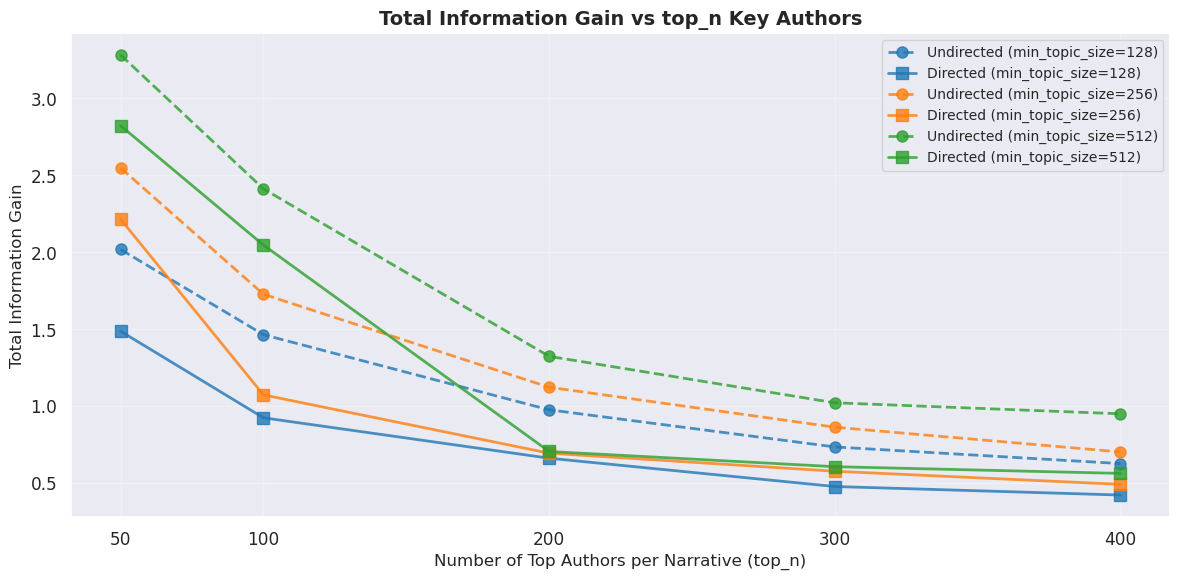

In [133]:
# Plot ig_mean vs top_n (optional)
plot_ig_grid_results(
    grid_df=grid_df,
    y_col="ig_sum",
    output_path=folder_output_path,
)

# Graph Level Indicators

## Network-Level Indicators

In [ ]:
def iter_time_periods(
    df: pd.DataFrame,
    time_col: str = "post_time",
    freq: str = "7D",
    closed: str = "left"
):
    """Split DataFrame into time periods and yield (start, end, label, df_slice) tuples.
    
    Args:
        df: DataFrame with datetime time_col
        time_col: Column name with timestamps
        freq: Pandas frequency string (e.g., '7D', 'W-MON', 'MS')
        closed: 'left' for [start, end) or 'right' for (start, end]
        
    Yields:
        (period_start, period_end, period_label, df_slice) where:
        - period_start: datetime start of the period
        - period_end: datetime end of the period
        - period_label: string like "2025-01-01_to_2025-01-08"
        - df_slice: DataFrame subset for this period
    """
    if time_col not in df.columns:
        raise ValueError(f"Time column '{time_col}' not found in DataFrame")
    
    if df[time_col].isna().any():
        raise ValueError(f"Time column '{time_col}' contains NaN values. Call validate_time_column() first.")
    
    min_time = df[time_col].min()
    max_time = df[time_col].max()
    
    # Generate period bins
    bins = pd.date_range(start=min_time.floor('D'), end=max_time.ceil('D'), freq=freq)
    
    # If last bin doesn't cover max_time, add one more
    if bins[-1] < max_time:
        bins = bins.append(pd.DatetimeIndex([bins[-1] + pd.Timedelta(freq)]))
    
    print(f"Splitting into {len(bins)-1} periods (freq={freq}, closed={closed})")
    print(f"  Date range: {min_time.date()} to {max_time.date()}")
    
    for i in range(len(bins) - 1):
        period_start = bins[i]
        period_end = bins[i + 1]
        
        # Create label
        period_label = f"{period_start.strftime('%Y-%m-%d')}_to_{period_end.strftime('%Y-%m-%d')}"
        
        # Filter data based on closed parameter
        if closed == "left":
            mask = (df[time_col] >= period_start) & (df[time_col] < period_end)
        elif closed == "right":
            mask = (df[time_col] > period_start) & (df[time_col] <= period_end)
        else:
            raise ValueError(f"closed must be 'left' or 'right', got '{closed}'")
        
        df_slice = df[mask]
        
        yield period_start, period_end, period_label, df_slice

: 

: 

: 

: 

In [ ]:
def validate_time_column(
    df: pd.DataFrame, 
    time_col: str = "post_time",
    max_missing_pct: float = 0.05
) -> pd.DataFrame:
    """Validate and ensure time column is datetime, drop rows with missing timestamps.
    
    Args:
        df: Input DataFrame
        time_col: Name of the timestamp column
        max_missing_pct: Maximum allowed percentage of missing timestamps (fail if exceeded)
        
    Returns:
        DataFrame with validated datetime column (missing timestamps dropped)
        
    Raises:
        ValueError: If time column doesn't exist or too many missing values
    """
    if time_col not in df.columns:
        raise ValueError(f"Time column '{time_col}' not found in DataFrame. Available: {df.columns.tolist()}")
    
    # Check missing values
    n_missing = df[time_col].isna().sum()
    pct_missing = n_missing / len(df) if len(df) > 0 else 0
    
    if pct_missing > max_missing_pct:
        raise ValueError(
            f"Too many missing timestamps: {n_missing:,} ({pct_missing:.1%}) > {max_missing_pct:.1%}. "
            "Research context requires explicit failure rather than silent data loss."
        )
    
    if n_missing > 0:
        print(f"Dropping {n_missing:,} rows ({pct_missing:.2%}) with missing {time_col}")
        df = df[df[time_col].notna()].copy()
    
    # Ensure datetime
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        print(f"Converting {time_col} to datetime")
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        # Check for conversion failures
        n_failed = df[time_col].isna().sum()
        if n_failed > 0:
            print(f"Warning: {n_failed:,} timestamps failed conversion, dropping them")
            df = df[df[time_col].notna()].copy()
    
    return df

: 

: 

: 

: 

## Time Period Utilities

In [ ]:
def compute_graph_level_indicators(G: nx.Graph) -> dict:
    """Compute network-level indicators for a graph.
    
    Computes extended set of graph-level metrics including:
    - Size/shape: n_nodes, n_edges, density, is_directed
    - Degree: mean/median in/out-degree (directed) or degree (undirected)
    - Connectivity: components, largest component size
    - Structure: transitivity, avg clustering
    - Reciprocity (directed only)
    - Assortativity: degree assortativity
    - Distance: avg shortest path, diameter (on largest component)
    
    Args:
        G: NetworkX graph (directed or undirected)
        
    Returns:
        Dictionary of indicator name -> value
    """
    indicators = {}
    
    # Basic size/shape
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    
    indicators["n_nodes"] = n_nodes
    indicators["n_edges"] = n_edges
    indicators["is_directed"] = G.is_directed()
    
    # Density (handle empty graph)
    try:
        indicators["density"] = nx.density(G) if n_nodes > 0 else 0.0
    except:
        indicators["density"] = np.nan
    
    # Degree statistics
    if n_nodes > 0:
        if G.is_directed():
            in_degrees = [d for n, d in G.in_degree()]
            out_degrees = [d for n, d in G.out_degree()]
            indicators["mean_in_degree"] = np.mean(in_degrees) if in_degrees else 0.0
            indicators["median_in_degree"] = np.median(in_degrees) if in_degrees else 0.0
            indicators["mean_out_degree"] = np.mean(out_degrees) if out_degrees else 0.0
            indicators["median_out_degree"] = np.median(out_degrees) if out_degrees else 0.0
        else:
            degrees = [d for n, d in G.degree()]
            indicators["mean_degree"] = np.mean(degrees) if degrees else 0.0
            indicators["median_degree"] = np.median(degrees) if degrees else 0.0
    else:
        if G.is_directed():
            indicators["mean_in_degree"] = 0.0
            indicators["median_in_degree"] = 0.0
            indicators["mean_out_degree"] = 0.0
            indicators["median_out_degree"] = 0.0
        else:
            indicators["mean_degree"] = 0.0
            indicators["median_degree"] = 0.0
    
    # Connectivity (components)
    if G.is_directed():
        # Weakly connected components
        wcc = list(nx.weakly_connected_components(G))
        indicators["n_wcc"] = len(wcc)
        indicators["largest_wcc_size"] = len(max(wcc, key=len)) if wcc else 0
        
        # Strongly connected components
        scc = list(nx.strongly_connected_components(G))
        indicators["n_scc"] = len(scc)
        indicators["largest_scc_size"] = len(max(scc, key=len)) if scc else 0
    else:
        # Connected components (undirected)
        cc = list(nx.connected_components(G))
        indicators["n_components"] = len(cc)
        indicators["largest_component_size"] = len(max(cc, key=len)) if cc else 0
    
    # Transitivity and clustering (computed on undirected version)
    try:
        G_undir = G.to_undirected() if G.is_directed() else G
        indicators["transitivity"] = nx.transitivity(G_undir)
        indicators["average_clustering"] = nx.average_clustering(G_undir)
    except:
        indicators["transitivity"] = np.nan
        indicators["average_clustering"] = np.nan
    
    # Reciprocity (directed graphs only)
    if G.is_directed():
        try:
            indicators["reciprocity"] = nx.reciprocity(G)
        except:
            indicators["reciprocity"] = np.nan
    
    # Assortativity (degree)
    try:
        indicators["degree_assortativity"] = nx.degree_assortativity_coefficient(G)
    except:
        indicators["degree_assortativity"] = np.nan
    
    # Distance metrics (on largest component to avoid inf values)
    try:
        if G.is_directed():
            # Use largest weakly connected component
            if wcc and len(wcc[0]) > 1:
                largest_wcc = G.subgraph(max(wcc, key=len)).copy()
                # Convert to undirected for distance metrics
                largest_comp = largest_wcc.to_undirected()
            else:
                largest_comp = None
        else:
            # Use largest connected component
            if cc and len(cc[0]) > 1:
                largest_comp = G.subgraph(max(cc, key=len)).copy()
            else:
                largest_comp = None
        
        if largest_comp and nx.is_connected(largest_comp):
            indicators["avg_shortest_path_length"] = nx.average_shortest_path_length(largest_comp)
            indicators["diameter"] = nx.diameter(largest_comp)
        else:
            indicators["avg_shortest_path_length"] = np.nan
            indicators["diameter"] = np.nan
    except:
        indicators["avg_shortest_path_length"] = np.nan
        indicators["diameter"] = np.nan
    
    return indicators

: 

: 

: 

: 

In [ ]:
def build_period_graphs_and_compute_indicators(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    io_authors_set: set,
    all_topics_key_authors_df: pd.DataFrame,
    output_base_path: Path,
    topic_col: str = "BERTopic_topic_512",
    time_col: str = "post_time",
    freq: str = "7D",
    closed: str = "left",
    is_directed_graphs: bool = True,
    max_missing_time_pct: float = 0.05,
) -> pd.DataFrame:
    """Build graphs for each time period and compute network-level indicators.
    
    Pipeline:
    1. Validate time column
    2. Split data into time periods
    3. For each period:
       - Build graph using global key-author set
       - Export graph to GEXF
       - Compute network-level indicators
    4. Aggregate all indicators into one DataFrame
    5. Save aggregated indicators table
    
    Args:
        df: Posts DataFrame with timestamp column
        account_relations: List of (src_col, dst_col) relations for graph edges
        io_authors_set: Set of IO author IDs (computed globally)
        all_topics_key_authors_df: Key authors DataFrame (computed globally)
        output_base_path: Base directory for outputs
        topic_col: Topic column name for graph naming
        time_col: Timestamp column name
        freq: Pandas frequency string for period bins (e.g., '7D', 'W-MON')
        closed: 'left' for [start, end) or 'right' for (start, end]
        is_directed_graphs: Whether to build directed graphs
        max_missing_time_pct: Maximum allowed percentage of missing timestamps
        
    Returns:
        DataFrame with one row per period containing network-level indicators
    """
    # 1. Validate time column
    print("=" * 80)
    print("PERIOD-SLICED GRAPH PIPELINE")
    print("=" * 80)
    df = validate_time_column(df, time_col=time_col, max_missing_pct=max_missing_time_pct)
    print(f"Total posts after time validation: {len(df):,}")
    print()
    
    # Create output directory for period graphs
    period_graphs_dir = output_base_path / "period_graphs"
    period_graphs_dir.mkdir(exist_ok=True, parents=True)
    print(f"Output directory: {period_graphs_dir}")
    print()
    
    # 2. Split into periods and build graphs
    all_period_indicators = []
    
    for period_start, period_end, period_label, df_slice in iter_time_periods(
        df, time_col=time_col, freq=freq, closed=closed
    ):
        n_posts = len(df_slice)
        n_unique_authors = df_slice["accountid"].nunique() if "accountid" in df_slice.columns else 0
        
        print(f"\n{'─' * 80}")
        print(f"Period: {period_label}")
        print(f"  Range: {period_start} to {period_end} (closed={closed})")
        print(f"  Posts: {n_posts:,}")
        print(f"  Unique authors: {n_unique_authors:,}")
        
        # Skip empty periods
        if n_posts == 0:
            print("  ⚠ Skipping empty period")
            continue
        
        # Create period-specific output directory
        period_output_dir = period_graphs_dir / period_label
        period_output_dir.mkdir(exist_ok=True, parents=True)
        
        # Build graph for this period (using global key-author set)
        graph_name = f"{topic_col}__{period_label}"
        try:
            G_period = build_accounts_graph(
                df=df_slice,
                account_relations=account_relations,
                io_authors=io_authors_set,
                all_topics_key_authors_df=all_topics_key_authors_df,
                output_path=period_output_dir,
                topic_col=graph_name,
                is_directed_graphs=is_directed_graphs,
            )
            
            print(f"  Graph: {G_period.number_of_nodes()} nodes, {G_period.number_of_edges()} edges")
            
            # Compute network-level indicators
            indicators = compute_graph_level_indicators(G_period)
            
            # Add period metadata
            indicators["period_start"] = period_start
            indicators["period_end"] = period_end
            indicators["period_label"] = period_label
            indicators["n_posts_in_period"] = n_posts
            indicators["n_unique_authors_in_period"] = n_unique_authors
            indicators["topic_col"] = topic_col
            
            all_period_indicators.append(indicators)
            print(f"  ✓ Computed {len(indicators)} indicators")
            
        except Exception as e:
            print(f"  ✗ Error building graph: {e}")
            continue
    
    # 3. Aggregate indicators
    print(f"\n{'═' * 80}")
    print(f"AGGREGATING INDICATORS")
    print(f"{'═' * 80}")
    
    if not all_period_indicators:
        print("⚠ No period graphs were built successfully")
        return pd.DataFrame()
    
    indicators_df = pd.DataFrame(all_period_indicators)
    
    # Reorder columns: period metadata first, then indicators
    metadata_cols = ["period_label", "period_start", "period_end", "n_posts_in_period", 
                     "n_unique_authors_in_period", "topic_col"]
    other_cols = [c for c in indicators_df.columns if c not in metadata_cols]
    indicators_df = indicators_df[metadata_cols + other_cols]
    
    # Save aggregated table
    parquet_path = period_graphs_dir / "graph_level_indicators_by_period.parquet"
    csv_path = period_graphs_dir / "graph_level_indicators_by_period.csv"
    
    indicators_df.to_parquet(parquet_path, index=False, compression="gzip")
    indicators_df.to_csv(csv_path, index=False)
    
    print(f"\n✓ Saved aggregated indicators:")
    print(f"  - {parquet_path}")
    print(f"  - {csv_path}")
    print(f"\nTotal periods processed: {len(indicators_df)}")
    print(f"Indicator columns: {len(other_cols)}")
    
    # Print summary statistics
    print(f"\n{'─' * 80}")
    print("SUMMARY STATISTICS")
    print(f"{'─' * 80}")
    
    if "density" in indicators_df.columns:
        print(f"Density range: {indicators_df['density'].min():.4f} to {indicators_df['density'].max():.4f}")
    
    if "n_nodes" in indicators_df.columns:
        print(f"Nodes range: {indicators_df['n_nodes'].min():.0f} to {indicators_df['n_nodes'].max():.0f}")
        print(f"Edges range: {indicators_df['n_edges'].min():.0f} to {indicators_df['n_edges'].max():.0f}")
    
    if "largest_wcc_size" in indicators_df.columns:
        print(f"Largest WCC size range: {indicators_df['largest_wcc_size'].min():.0f} to {indicators_df['largest_wcc_size'].max():.0f}")
    elif "largest_component_size" in indicators_df.columns:
        print(f"Largest component size range: {indicators_df['largest_component_size'].min():.0f} to {indicators_df['largest_component_size'].max():.0f}")
    
    return indicators_df

: 

: 

: 

: 

In [ ]:
# Plot key indicators over time
if not period_indicators_df.empty:
    plot_period_indicators(period_indicators_df, output_path=folder_output_path)

: 

: 

: 

: 

In [ ]:
def plot_period_indicators(
    indicators_df: pd.DataFrame,
    metrics: list[str] = None,
    output_path: Path | None = None,
):
    """Plot network indicators over time periods.
    
    Args:
        indicators_df: DataFrame from build_period_graphs_and_compute_indicators
        metrics: List of metric column names to plot (default: key metrics)
        output_path: Optional directory to save plots
    """
    if indicators_df.empty:
        print("No data to plot")
        return
    
    # Default metrics if not specified
    if metrics is None:
        metrics = [
            "n_nodes", "n_edges", "density", 
            "transitivity", "average_clustering",
            "reciprocity" if "reciprocity" in indicators_df.columns else None,
        ]
        metrics = [m for m in metrics if m and m in indicators_df.columns]
    
    # Filter to available metrics
    metrics = [m for m in metrics if m in indicators_df.columns]
    
    if not metrics:
        print("No valid metrics to plot")
        return
    
    n_metrics = len(metrics)
    n_cols = 2
    n_rows = (n_metrics + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Use period_start as x-axis
        x = indicators_df["period_start"]
        y = indicators_df[metric]
        
        ax.plot(x, y, marker='o', linewidth=2, markersize=6)
        ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel("Period Start", fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        ax.grid(alpha=0.3)
        
        # Rotate x-axis labels
        ax.tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if output_path:
        output_path = Path(output_path)
        plot_file = output_path / "period_graphs" / "indicators_over_time.png"
        plt.savefig(plot_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {plot_file}")
    
    plt.show()
    plt.close()

: 

: 

: 

: 

## Visualize Indicators Over Time

In [ ]:
# Display the aggregated indicators table
display(period_indicators_df)

: 

: 

: 

: 

In [ ]:
# Run period-sliced graph pipeline
# Uses 7-day bins, left-closed intervals [start, end)
# Key authors and IO authors are computed globally (already available in notebook variables)

period_indicators_df = build_period_graphs_and_compute_indicators(
    df=df,
    account_relations=account_relations,
    io_authors_set=io_authors_set,
    all_topics_key_authors_df=all_topics_key_authors_df,
    output_base_path=folder_output_path,
    topic_col=topic_col,
    time_col="post_time",
    freq="7D",  # 7-day periods
    closed="left",  # [start, end)
    is_directed_graphs=True,
    max_missing_time_pct=0.05,
)

: 

: 

: 

: 

## Example Usage: Build Period Graphs

Run the period-sliced graph pipeline using the globally-computed key authors and IO authors.

## Period-Sliced Graph Pipeline